In [5]:
 print("Human Activity Recognition Project Started")



Human Activity Recognition Project Started


# Human Activity Recognition Using Smartphones

Mini Project – Machine Learning & Deep Learning


In [5]:
pip install pandas 


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\hi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [36]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\hi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


##  Import Required Libraries
In this step, we import the necessary libraries for data handling and preprocessing.

In [7]:
import numpy as np
import pandas as pd
import os

##  Define Dataset Path
Here we define the main folder path where the UCI HAR dataset is stored.

In [ ]:
dataset_path = "UCI HAR Dataset"

##  training and testing the data

In [9]:
import pandas as pd
import numpy as np

# Load dataset
X_train = pd.read_csv("train/X_train.txt", sep=r"\s+", header=None)
y_train = pd.read_csv("train/y_train.txt", header=None)

X_test = pd.read_csv("test/X_test.txt", sep=r"\s+", header=None)
y_test = pd.read_csv("test/y_test.txt", header=None)

# Convert labels to 1D array
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

# Print shapes
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

# Check first few labels
print("Sample training labels:", y_train[:10])


Training data shape: (7352, 561)
Training labels shape: (7352,)
Testing data shape: (2947, 561)
Testing labels shape: (2947,)
Sample training labels: [5 5 5 5 5 5 5 5 5 5]


## Import Machine Learning Libraries


In [10]:
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

##  Train and Evaluate Logistic Regression


In [11]:
# Create model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train, y_train)

# Predict
y_pred_log = log_model.predict(X_test)

# Accuracy
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.9609772650152698


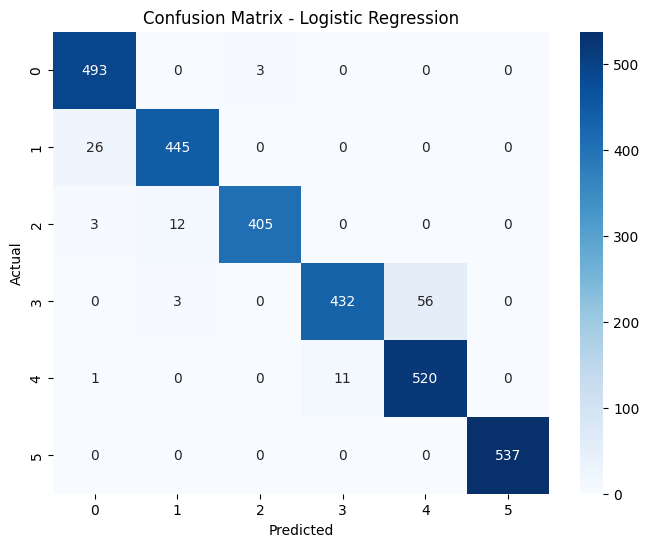

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(8,6))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##  Train and Evaluate Decision Tree Model

In [37]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8622327790973872


In [39]:
from sklearn.metrics import classification_report

print("Decision Tree Classification Report:\n")

print(classification_report(
    y_test,
    y_pred_dt,
    target_names=activity_labels
))

Decision Tree Classification Report:

                    precision    recall  f1-score   support

           WALKING       0.83      0.92      0.87       496
  WALKING_UPSTAIRS       0.83      0.78      0.80       471
WALKING_DOWNSTAIRS       0.89      0.83      0.86       420
           SITTING       0.83      0.76      0.80       491
          STANDING       0.80      0.86      0.83       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.86      2947
         macro avg       0.86      0.86      0.86      2947
      weighted avg       0.86      0.86      0.86      2947



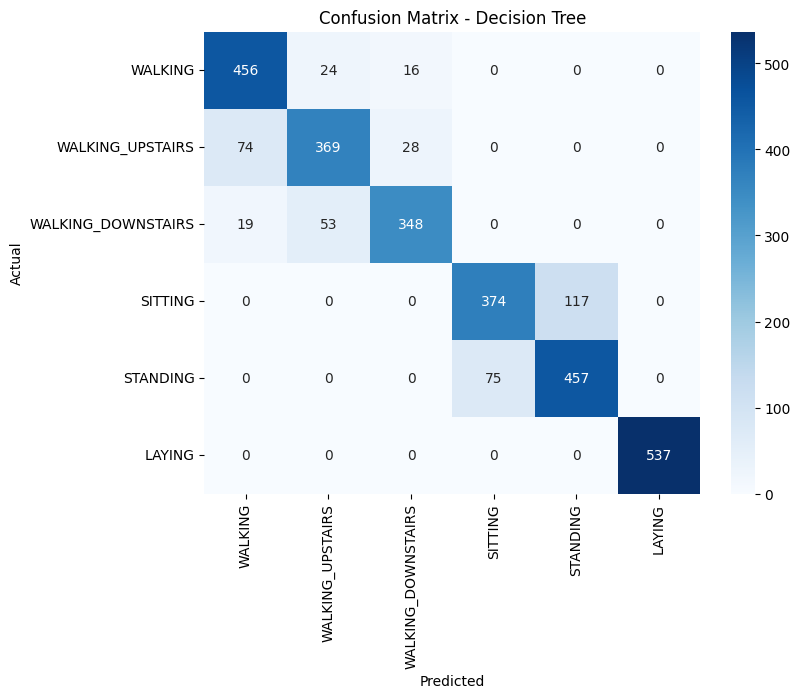

In [43]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8,6))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues",
            xticklabels=activity_labels,
            yticklabels=activity_labels)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##  Train and Evaluate Random Forest Model


In [12]:
# Create Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9256871394638616


In [13]:
from sklearn.metrics import classification_report

activity_labels = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=activity_labels))

Random Forest Classification Report:

                    precision    recall  f1-score   support

           WALKING       0.89      0.97      0.93       496
  WALKING_UPSTAIRS       0.90      0.89      0.89       471
WALKING_DOWNSTAIRS       0.97      0.87      0.91       420
           SITTING       0.91      0.89      0.90       491
          STANDING       0.90      0.92      0.91       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.93      0.93      2947



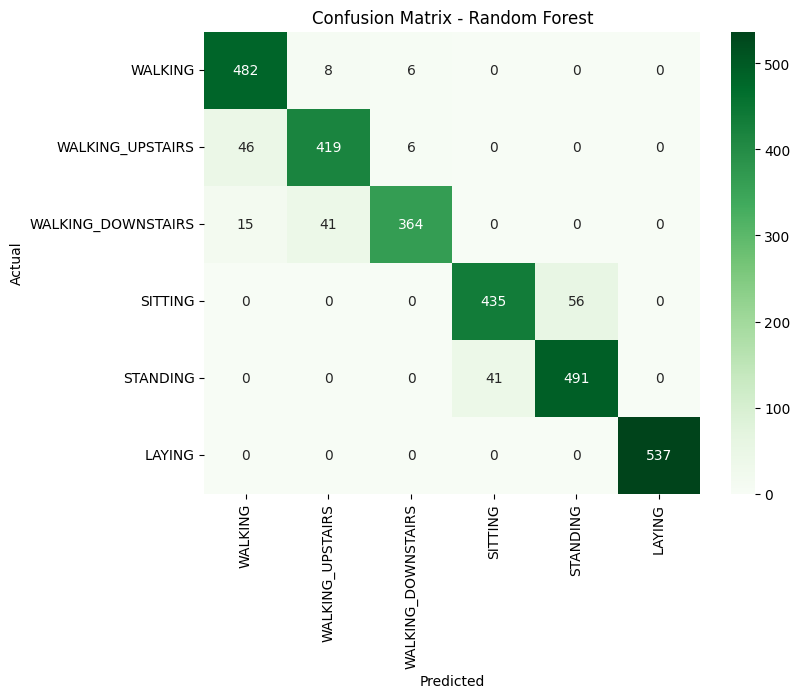

In [44]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=activity_labels,
            yticklabels=activity_labels)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Train and Evaluate K-Nearest Neighbors (KNN) Model


In [14]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train model
knn_model.fit(X_train, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test)

# Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9015948422124194


In [15]:
print("KNN Classification Report:\n")
print(classification_report(y_test, y_pred_knn, target_names=activity_labels))

KNN Classification Report:

                    precision    recall  f1-score   support

           WALKING       0.85      0.98      0.91       496
  WALKING_UPSTAIRS       0.89      0.90      0.90       471
WALKING_DOWNSTAIRS       0.95      0.79      0.86       420
           SITTING       0.91      0.79      0.85       491
          STANDING       0.83      0.93      0.88       532
            LAYING       1.00      0.99      1.00       537

          accuracy                           0.90      2947
         macro avg       0.91      0.90      0.90      2947
      weighted avg       0.91      0.90      0.90      2947



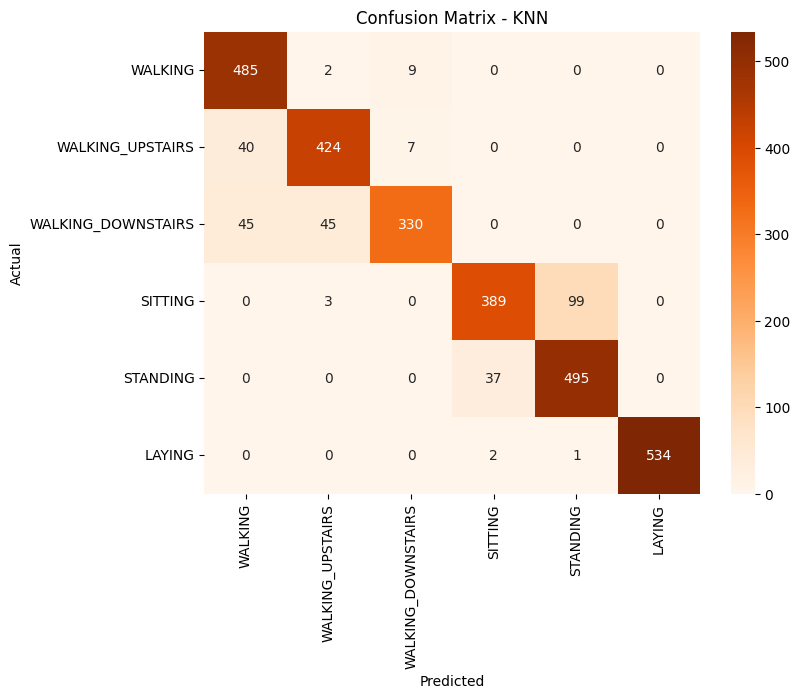

In [45]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8,6))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Oranges",
            xticklabels=activity_labels,
            yticklabels=activity_labels)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Train and Evaluate Support Vector Machine (SVM)

In [40]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9504580929759077


In [41]:
from sklearn.metrics import classification_report

print("SVM Classification Report:\n")

print(classification_report(
    y_test,
    y_pred_svm,
    target_names=activity_labels
))

SVM Classification Report:

                    precision    recall  f1-score   support

           WALKING       0.94      0.98      0.96       496
  WALKING_UPSTAIRS       0.93      0.96      0.94       471
WALKING_DOWNSTAIRS       0.99      0.91      0.95       420
           SITTING       0.94      0.89      0.91       491
          STANDING       0.91      0.95      0.93       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



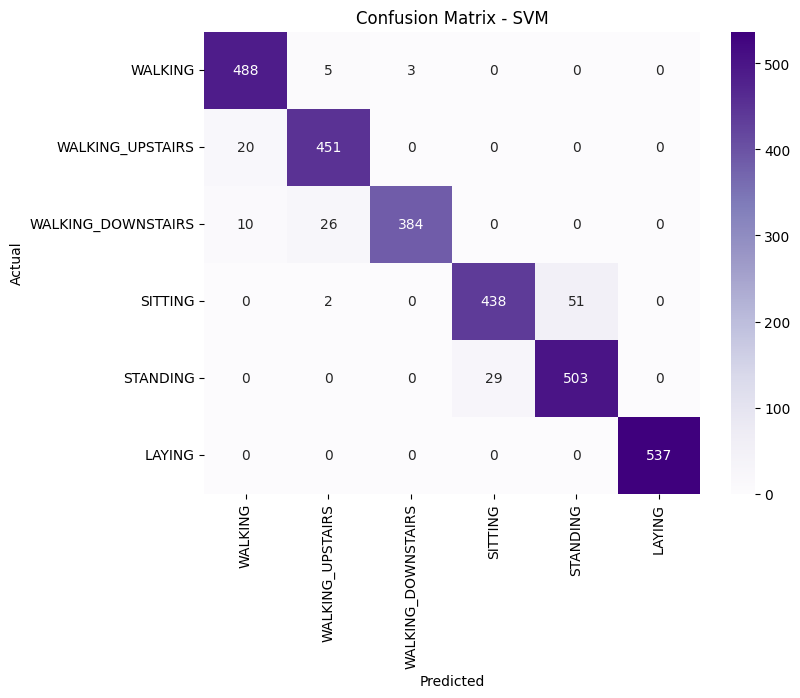

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Purples",
            xticklabels=activity_labels,
            yticklabels=activity_labels)

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Performance Comparison

In [47]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "KNN", "SVM"],
    "Accuracy": [0.8622, 0.925, 0.901, 0.95]
})

results

,Model,Accuracy
0,Decision Tree,0.8622
1,Random Forest,0.9250
2,KNN,0.9010
3,SVM,0.9500


## Model Comparison Graph

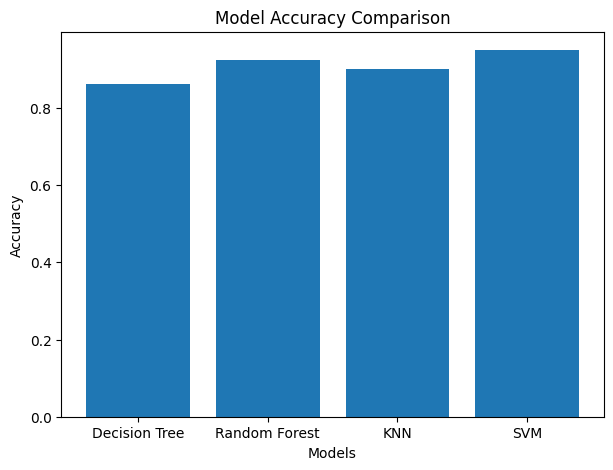

In [46]:
models = ["Decision Tree", "Random Forest", "KNN", "SVM"]
accuracies = [0.8622, 0.925, 0.901, 0.95]

plt.figure(figsize=(7,5))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()

In [29]:
import sys
!{sys.executable} -m pip install shap
!{sys.executable} -m pip install lime

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\hi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\hi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [35]:
import shap
import lime